# Pupil & Gaze Deep Dive: Decision Uncertainty Signatures

**Purpose**: Analyze pupil dynamics and gaze patterns as indices of decision uncertainty and commitment.

**Key Analyses**:
1. **Pupil time course visualization**: INVEST vs KEEP trajectories
2. **Gaze dispersion as uncertainty index**: Reduced exploration = decision commitment
3. **Pupil-gaze correlations**: Do they track the same uncertainty signal?
4. **Ambiguity modulation**: How do these signals change with task uncertainty?

**Neuroscience Background**:
- Pupil dilation reflects LC-NE (locus coeruleus-norepinephrine) arousal system activity
- Steeper pupil dilation = higher uncertainty/cognitive load
- Gaze exploration reflects information sampling; reduced dispersion = attentional commitment

In [1]:
import sys
sys.path.append('../..')

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from datetime import datetime
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
PREPROCESSING_DIR = Path('../../data/results/preprocessing')
OUTPUT_DIR = Path('../../data/results/main/statistical_analyses/pupil_gaze_deep_dive')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"{'='*70}")
print(f"PUPIL & GAZE DEEP DIVE: DECISION UNCERTAINTY SIGNATURES")
print(f"{'='*70}")
print(f"Analysis started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

PUPIL & GAZE DEEP DIVE: DECISION UNCERTAINTY SIGNATURES
Analysis started: 2026-04-17 12:06:52


## 1. Load Data

In [2]:
# Load extracted features for outcome and ambiguity info
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
gaze_cols = feature_data['gaze_cols']

# Create lookup for outcomes and ambiguity
outcome_lookup = dict(zip(merged_df['trial_id'], merged_df['outcome']))
ambiguity_lookup = dict(zip(merged_df['trial_id'], merged_df['ambiguity']))

print(f"Loaded {len(merged_df)} trials")
print(f"Physio features: {physio_cols}")
print(f"\nGaze features: {gaze_cols}")

Loaded 12107 trials
Physio features: ['pupil_mean_pre', 'pupil_std_pre', 'pupil_slope_pre', 'time_to_peak_pre', 'pupil_cv_pre', 'pupil_velocity_mean_pre', 'pupil_max_dilation_rate_pre', 'pupil_max_constriction_rate_pre', 'pupil_acceleration_std_pre', 'pct_time_dilating_pre', 'num_dilation_peaks_pre', 'eye_asymmetry_pre', 'eye_asymmetry_std_pre']

Gaze features: ['gaze_valid_pct', 'gaze_x_mean', 'gaze_x_std', 'gaze_y_mean', 'gaze_y_std', 'screen_x_mean', 'screen_x_std', 'screen_y_mean', 'screen_y_std', 'gaze_velocity_mean', 'gaze_velocity_std', 'gaze_velocity_max', 'gaze_acceleration_mean', 'gaze_acceleration_std', 'fixation_ratio', 'saccade_ratio', 'saccade_count', 'gaze_dispersion_x', 'gaze_dispersion_y', 'gaze_path_length']


## 2. Analysis 1: Pupil Time Course (INVEST vs KEEP)

In [3]:
# Load raw pupil time series from preprocessing files
BASELINE_METHOD = 't3_stable_pre_decision'

preprocessing_files = sorted(PREPROCESSING_DIR.glob('preprocessing_*.json'))
print(f"Found {len(preprocessing_files)} preprocessing files")

# Collect pupil time series
pupil_traces_invest = []
pupil_traces_keep = []
pupil_traces_by_ambiguity = {'Low': {'invest': [], 'keep': []},
                              'Medium': {'invest': [], 'keep': []},
                              'High': {'invest': [], 'keep': []}}

# Common time grid for alignment
TIME_GRID = np.linspace(-2.0, 0.0, 100)  # 100 points from -2s to 0s

for preprocessed_file in tqdm(preprocessing_files, desc="Loading pupil traces"):
    with open(preprocessed_file, 'r') as f:
        preprocessed = json.load(f)
    
    subject_id = preprocessed['subject_id']
    
    for trial_id, trial_data in preprocessed['trial_data'].items():
        method_data = trial_data['methods'][BASELINE_METHOD]
        
        if method_data['success'] != True:
            continue
        
        lookup_key = f"{trial_id}_{subject_id}"
        if lookup_key not in outcome_lookup:
            continue
        
        outcome = outcome_lookup[lookup_key]
        ambiguity = ambiguity_lookup[lookup_key]
        amb_group = {0: 'Low', 3: 'Medium', 6: 'High'}.get(ambiguity, None)
        
        # Get pupil trace
        time_aligned = np.array(trial_data['time_relative_to_submit'])
        pupil_avg = np.array(method_data['pupil_avg_baselined'])
        
        # Clean and interpolate to common grid
        valid_mask = ~np.isnan(pupil_avg)
        if valid_mask.sum() < 20:
            continue
        
        time_clean = time_aligned[valid_mask]
        pupil_clean = pupil_avg[valid_mask]
        
        # Interpolate to common time grid
        try:
            pupil_interp = np.interp(TIME_GRID, time_clean, pupil_clean)
        except:
            continue
        
        # Store by outcome
        if outcome == 1:
            pupil_traces_invest.append(pupil_interp)
        else:
            pupil_traces_keep.append(pupil_interp)
        
        # Store by ambiguity
        if amb_group:
            choice = 'invest' if outcome == 1 else 'keep'
            pupil_traces_by_ambiguity[amb_group][choice].append(pupil_interp)

pupil_traces_invest = np.array(pupil_traces_invest)
pupil_traces_keep = np.array(pupil_traces_keep)

print(f"\nLoaded pupil traces:")
print(f"  INVEST: {len(pupil_traces_invest)} trials")
print(f"  KEEP: {len(pupil_traces_keep)} trials")

Found 105 preprocessing files


Loading pupil traces: 100%|██████████| 105/105 [02:04<00:00,  1.19s/it]


Loaded pupil traces:
  INVEST: 7910 trials
  KEEP: 4197 trials



Timepoint-wise t-tests (INVEST vs KEEP):
  Significant (p<0.001) from -2.00s to 0.00s


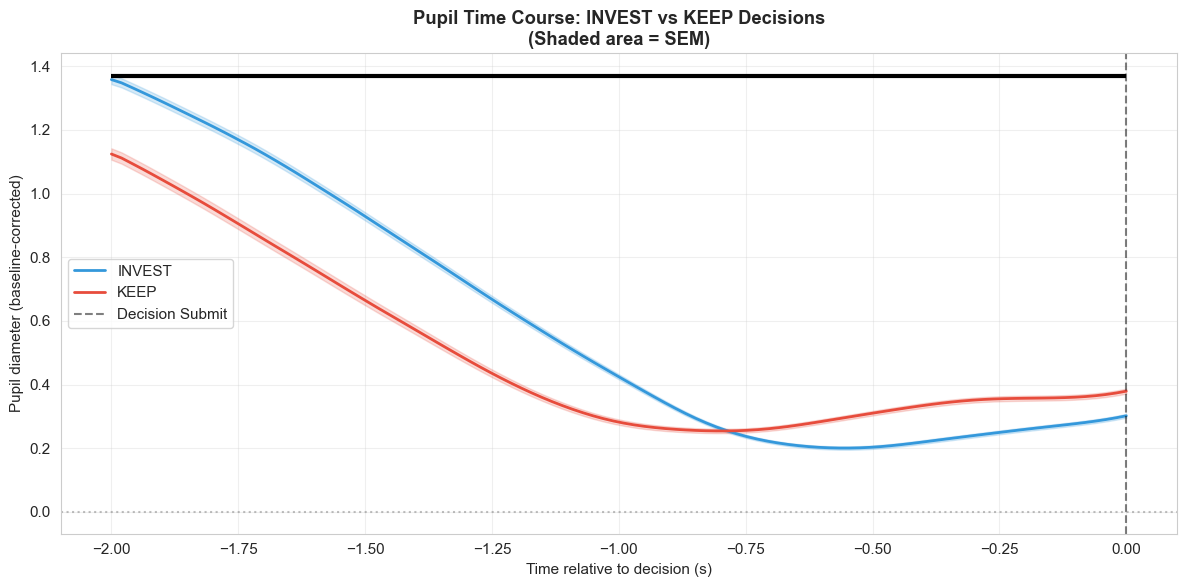

In [4]:
# Plot: Pupil time course INVEST vs KEEP
fig, ax = plt.subplots(figsize=(12, 6))

# Compute mean and SEM
invest_mean = pupil_traces_invest.mean(axis=0)
invest_sem = pupil_traces_invest.std(axis=0) / np.sqrt(len(pupil_traces_invest))

keep_mean = pupil_traces_keep.mean(axis=0)
keep_sem = pupil_traces_keep.std(axis=0) / np.sqrt(len(pupil_traces_keep))

# Plot with shaded SEM
ax.plot(TIME_GRID, invest_mean, color='#3498DB', linewidth=2, label='INVEST')
ax.fill_between(TIME_GRID, invest_mean - invest_sem, invest_mean + invest_sem, 
                color='#3498DB', alpha=0.2)

ax.plot(TIME_GRID, keep_mean, color='#E74C3C', linewidth=2, label='KEEP')
ax.fill_between(TIME_GRID, keep_mean - keep_sem, keep_mean + keep_sem, 
                color='#E74C3C', alpha=0.2)

ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='Decision Submit')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

ax.set_xlabel('Time relative to decision (s)')
ax.set_ylabel('Pupil diameter (baseline-corrected)')
ax.set_title('Pupil Time Course: INVEST vs KEEP Decisions\n(Shaded area = SEM)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Add significance markers
print("\nTimepoint-wise t-tests (INVEST vs KEEP):")
sig_times = []
for i, t in enumerate(TIME_GRID):
    t_stat, p_val = stats.ttest_ind(pupil_traces_invest[:, i], pupil_traces_keep[:, i])
    if p_val < 0.001:
        sig_times.append(t)

if sig_times:
    print(f"  Significant (p<0.001) from {min(sig_times):.2f}s to {max(sig_times):.2f}s")
    # Add significance bar
    y_pos = ax.get_ylim()[1] * 0.95
    ax.hlines(y_pos, min(sig_times), max(sig_times), colors='black', linewidth=3, label='p<0.001')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pupil_time_course_invest_vs_keep.png', dpi=300, bbox_inches='tight')
plt.show()

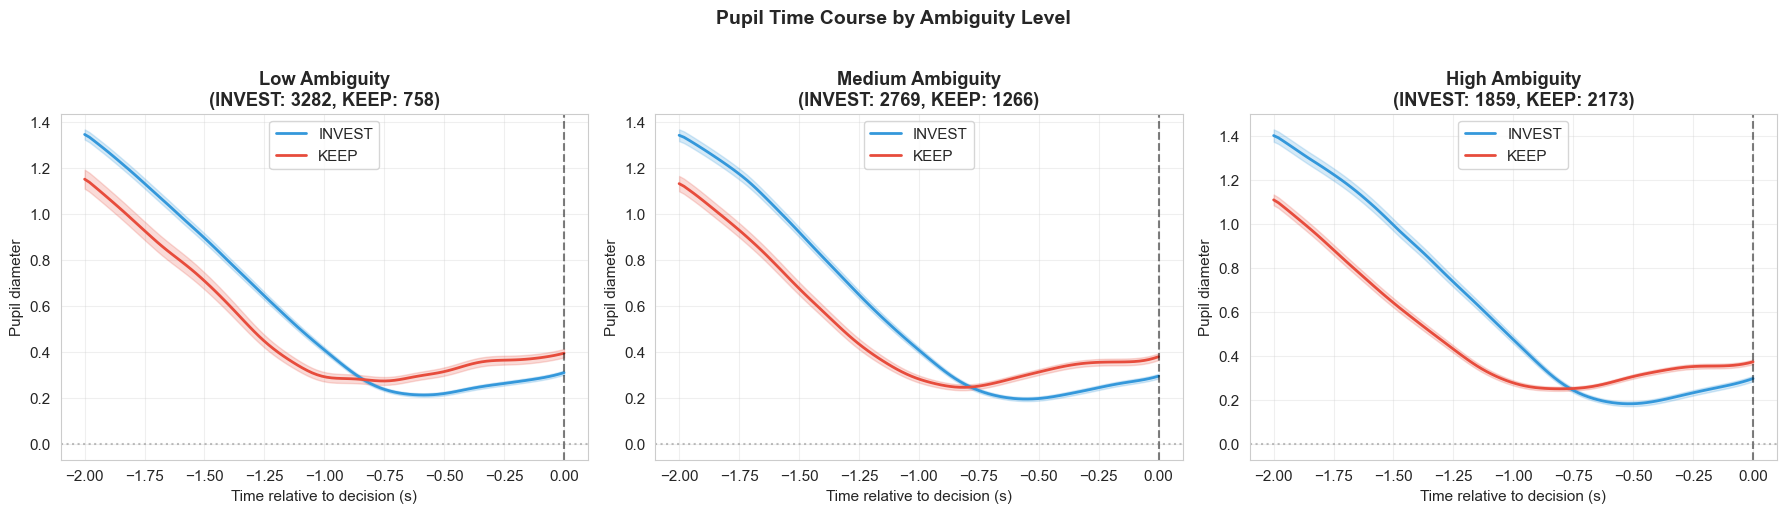

In [5]:
# Plot: Pupil time course by Ambiguity level
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, amb in enumerate(['Low', 'Medium', 'High']):
    ax = axes[idx]
    
    invest_traces = np.array(pupil_traces_by_ambiguity[amb]['invest'])
    keep_traces = np.array(pupil_traces_by_ambiguity[amb]['keep'])
    
    if len(invest_traces) == 0 or len(keep_traces) == 0:
        continue
    
    invest_mean = invest_traces.mean(axis=0)
    invest_sem = invest_traces.std(axis=0) / np.sqrt(len(invest_traces))
    
    keep_mean = keep_traces.mean(axis=0)
    keep_sem = keep_traces.std(axis=0) / np.sqrt(len(keep_traces))
    
    ax.plot(TIME_GRID, invest_mean, color='#3498DB', linewidth=2, label='INVEST')
    ax.fill_between(TIME_GRID, invest_mean - invest_sem, invest_mean + invest_sem, 
                    color='#3498DB', alpha=0.2)
    
    ax.plot(TIME_GRID, keep_mean, color='#E74C3C', linewidth=2, label='KEEP')
    ax.fill_between(TIME_GRID, keep_mean - keep_sem, keep_mean + keep_sem, 
                    color='#E74C3C', alpha=0.2)
    
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    
    ax.set_xlabel('Time relative to decision (s)')
    ax.set_ylabel('Pupil diameter')
    ax.set_title(f'{amb} Ambiguity\n(INVEST: {len(invest_traces)}, KEEP: {len(keep_traces)})', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Pupil Time Course by Ambiguity Level', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pupil_time_course_by_ambiguity.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Compute slope differences
print("\n" + "="*70)
print("PUPIL SLOPE ANALYSIS")
print("="*70)
print("\nPupil slope (rate of dilation) in the -1.5s to -0.5s window:")

# Focus on -1.5s to -0.5s window (where your effect is strongest)
slope_window = (TIME_GRID >= -1.5) & (TIME_GRID <= -0.5)
time_window = TIME_GRID[slope_window]

def compute_slope(trace, time):
    return np.polyfit(time, trace, 1)[0]

invest_slopes = [compute_slope(trace[slope_window], time_window) for trace in pupil_traces_invest]
keep_slopes = [compute_slope(trace[slope_window], time_window) for trace in pupil_traces_keep]

print(f"\n  INVEST: mean slope = {np.mean(invest_slopes):.6f} ± {np.std(invest_slopes):.6f}")
print(f"  KEEP:   mean slope = {np.mean(keep_slopes):.6f} ± {np.std(keep_slopes):.6f}")

t_stat, p_val = stats.ttest_ind(invest_slopes, keep_slopes)
d = (np.mean(invest_slopes) - np.mean(keep_slopes)) / np.sqrt(
    ((len(invest_slopes)-1)*np.var(invest_slopes) + (len(keep_slopes)-1)*np.var(keep_slopes)) / 
    (len(invest_slopes) + len(keep_slopes) - 2)
)

print(f"\n  t-test: t = {t_stat:.3f}, p = {p_val:.2e}")
print(f"  Cohen's d = {d:.3f}")
print(f"\n  Interpretation: KEEP decisions show {'steeper' if np.mean(keep_slopes) > np.mean(invest_slopes) else 'less steep'} pupil dilation")


PUPIL SLOPE ANALYSIS

Pupil slope (rate of dilation) in the -1.5s to -0.5s window:

  INVEST: mean slope = -0.789398 ± 1.690216
  KEEP:   mean slope = -0.356907 ± 1.414992

  t-test: t = -14.152, p = 4.16e-45
  Cohen's d = -0.270

  Interpretation: KEEP decisions show steeper pupil dilation


## 3. Analysis 2: Gaze Dispersion as Uncertainty Index

In [7]:
# Analyze gaze_x_std - your strongest effect (d = -0.49)
print("\n" + "="*70)
print("GAZE DISPERSION ANALYSIS")
print("="*70)

# Effect sizes for key gaze features
gaze_features_of_interest = ['gaze_x_std', 'gaze_dispersion_x', 'gaze_dispersion_y', 
                              'gaze_velocity_max', 'gaze_path_length']

print("\nGaze feature effect sizes (INVEST - KEEP):")
print("(Negative d = higher in KEEP, lower in INVEST)\n")

gaze_effects = []
for col in gaze_features_of_interest:
    if col not in merged_df.columns:
        continue
    
    invest_vals = merged_df[merged_df['outcome'] == 1][col].dropna()
    keep_vals = merged_df[merged_df['outcome'] == 0][col].dropna()
    
    t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
    
    n1, n2 = len(invest_vals), len(keep_vals)
    pooled_std = np.sqrt(((n1-1)*invest_vals.var() + (n2-1)*keep_vals.var()) / (n1+n2-2))
    d = (invest_vals.mean() - keep_vals.mean()) / pooled_std if pooled_std > 0 else 0
    
    gaze_effects.append({
        'feature': col,
        'cohens_d': d,
        'p_value': p_val,
        'invest_mean': invest_vals.mean(),
        'keep_mean': keep_vals.mean()
    })
    
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
    print(f"  {col}: d = {d:.3f}, p = {p_val:.2e} {sig}")

gaze_effects_df = pd.DataFrame(gaze_effects)


GAZE DISPERSION ANALYSIS

Gaze feature effect sizes (INVEST - KEEP):
(Negative d = higher in KEEP, lower in INVEST)

  gaze_x_std: d = -0.492, p = 2.81e-142 ***
  gaze_dispersion_x: d = -0.147, p = 1.49e-14 ***
  gaze_dispersion_y: d = -0.085, p = 8.02e-06 ***
  gaze_velocity_max: d = -0.099, p = 1.92e-07 ***
  gaze_path_length: d = -0.076, p = 6.28e-05 ***


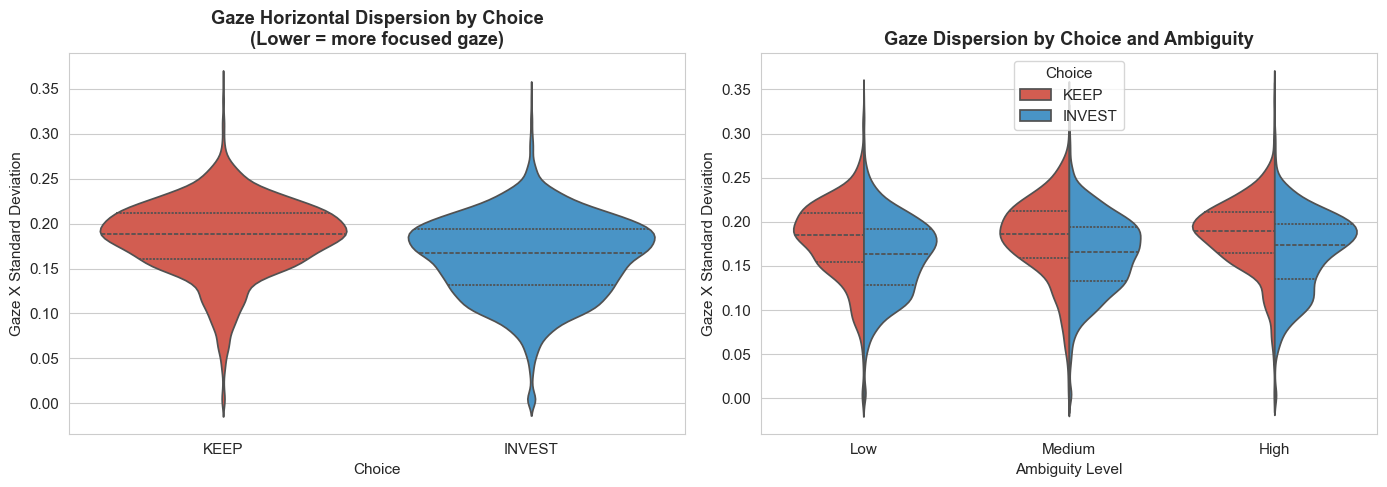

In [8]:
# Violin plot: Gaze X STD by choice and ambiguity
merged_df['ambiguity_group'] = merged_df['ambiguity'].replace({0: 'Low', 3: 'Medium', 6: 'High'})
merged_df['choice'] = merged_df['outcome'].map({0: 'KEEP', 1: 'INVEST'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall comparison
ax = axes[0]
sns.violinplot(data=merged_df, x='choice', y='gaze_x_std', 
               palette={'INVEST': '#3498DB', 'KEEP': '#E74C3C'},
               inner='quart', ax=ax)
ax.set_xlabel('Choice')
ax.set_ylabel('Gaze X Standard Deviation')
ax.set_title('Gaze Horizontal Dispersion by Choice\n(Lower = more focused gaze)', fontweight='bold')

# By ambiguity
ax = axes[1]
merged_df['ambiguity_group'] = pd.Categorical(merged_df['ambiguity_group'], 
                                               categories=['Low', 'Medium', 'High'], ordered=True)
sns.violinplot(data=merged_df, x='ambiguity_group', y='gaze_x_std', hue='choice',
               split=True, inner='quart', 
               palette={'INVEST': '#3498DB', 'KEEP': '#E74C3C'}, ax=ax)
ax.set_xlabel('Ambiguity Level')
ax.set_ylabel('Gaze X Standard Deviation')
ax.set_title('Gaze Dispersion by Choice and Ambiguity', fontweight='bold')
ax.legend(title='Choice')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gaze_dispersion_by_choice.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Gaze dispersion effect by ambiguity level
print("\n" + "="*70)
print("GAZE DISPERSION × AMBIGUITY")
print("="*70)

gaze_amb_results = []
for amb in ['Low', 'Medium', 'High']:
    amb_df = merged_df[merged_df['ambiguity_group'] == amb]
    invest_vals = amb_df[amb_df['outcome'] == 1]['gaze_x_std'].dropna()
    keep_vals = amb_df[amb_df['outcome'] == 0]['gaze_x_std'].dropna()
    
    n1, n2 = len(invest_vals), len(keep_vals)
    pooled_std = np.sqrt(((n1-1)*invest_vals.var() + (n2-1)*keep_vals.var()) / (n1+n2-2))
    d = (invest_vals.mean() - keep_vals.mean()) / pooled_std if pooled_std > 0 else 0
    t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
    
    gaze_amb_results.append({
        'ambiguity': amb,
        'cohens_d': d,
        'p_value': p_val,
        'invest_mean': invest_vals.mean(),
        'keep_mean': keep_vals.mean()
    })
    
    sig = '***' if p_val < 0.001 else ''
    print(f"\n{amb} Ambiguity:")
    print(f"  INVEST: {invest_vals.mean():.4f}, KEEP: {keep_vals.mean():.4f}")
    print(f"  Cohen's d = {d:.3f}, p = {p_val:.2e} {sig}")

gaze_amb_df = pd.DataFrame(gaze_amb_results)


GAZE DISPERSION × AMBIGUITY

Low Ambiguity:
  INVEST: 0.1598, KEEP: 0.1800
  Cohen's d = -0.453, p = 6.26e-29 ***

Medium Ambiguity:
  INVEST: 0.1632, KEEP: 0.1821
  Cohen's d = -0.428, p = 7.56e-36 ***

High Ambiguity:
  INVEST: 0.1658, KEEP: 0.1862
  Cohen's d = -0.486, p = 5.18e-52 ***


## 4. Analysis 3: Pupil-Gaze Correlation

Do pupil and gaze track the same underlying uncertainty signal?

In [10]:
# Correlate pupil slope with gaze dispersion
print("\n" + "="*70)
print("PUPIL-GAZE CORRELATIONS")
print("="*70)

# Key pupil features
pupil_features = ['pupil_slope_pre', 'pupil_std_pre', 'pct_time_dilating_pre']
# Key gaze features
gaze_features = ['gaze_x_std', 'gaze_dispersion_x', 'gaze_path_length']

print("\nCorrelations between pupil and gaze features:")
correlation_matrix = []

for pupil_col in pupil_features:
    row = {'pupil_feature': pupil_col}
    for gaze_col in gaze_features:
        if pupil_col in merged_df.columns and gaze_col in merged_df.columns:
            valid = merged_df[[pupil_col, gaze_col]].dropna()
            r, p = stats.pearsonr(valid[pupil_col], valid[gaze_col])
            row[gaze_col] = r
    correlation_matrix.append(row)

corr_df = pd.DataFrame(correlation_matrix).set_index('pupil_feature')
print(corr_df.round(3).to_string())


PUPIL-GAZE CORRELATIONS

Correlations between pupil and gaze features:
                       gaze_x_std  gaze_dispersion_x  gaze_path_length
pupil_feature                                                         
pupil_slope_pre             0.234              0.147             0.106
pupil_std_pre              -0.181             -0.168            -0.153
pct_time_dilating_pre       0.095              0.030             0.011


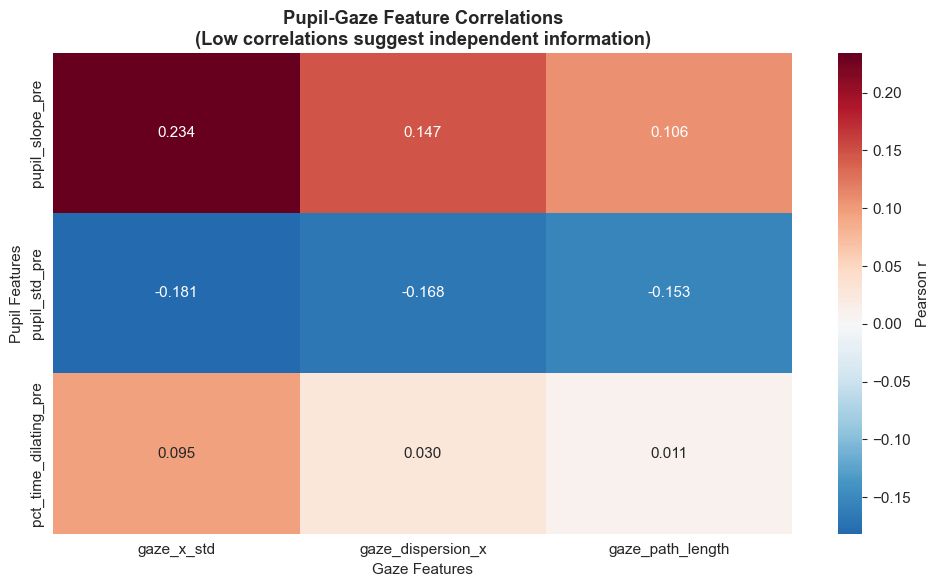


Interpretation:
  Low correlations (|r| < 0.3) suggest pupil and gaze capture different aspects
  of the decision process, justifying their separate inclusion in fusion models.


In [11]:
# Heatmap of correlations
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(corr_df, cmap='RdBu_r', center=0, annot=True, fmt='.3f',
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Pupil-Gaze Feature Correlations\n(Low correlations suggest independent information)', fontweight='bold')
ax.set_xlabel('Gaze Features')
ax.set_ylabel('Pupil Features')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pupil_gaze_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  Low correlations (|r| < 0.3) suggest pupil and gaze capture different aspects")
print("  of the decision process, justifying their separate inclusion in fusion models.")

## 5. Analysis 4: Temporal Alignment of Pupil and Gaze Effects

In [12]:
# Load temporal dynamics results if available
temporal_file = Path('../../data/results/main/statistical_analyses/temporal_dynamics/temporal_divergence_all.csv')

if temporal_file.exists():
    temporal_df = pd.read_csv(temporal_file)
    print("\n" + "="*70)
    print("TEMPORAL ALIGNMENT: WHEN DO SIGNALS EMERGE?")
    print("="*70)
    
    # Get peak time for each modality
    for modality in temporal_df['modality'].unique():
        mod_df = temporal_df[temporal_df['modality'] == modality]
        peak_row = mod_df.loc[mod_df['abs_cohens_d'].idxmax()]
        print(f"\n{modality.upper()}:")
        print(f"  Peak effect: {peak_row['feature']} at {peak_row['time_label']}")
        print(f"  Cohen's d = {peak_row['cohens_d']:.3f}")
else:
    print("Temporal dynamics file not found. Run 06_temporal_dynamics_analysis.ipynb first.")


TEMPORAL ALIGNMENT: WHEN DO SIGNALS EMERGE?

PUPIL:
  Peak effect: pupil_mean at -2.0s to -1.5s
  Cohen's d = 0.144

GAZE:
  Peak effect: gaze_velocity_mean at -2.0s to -1.5s
  Cohen's d = -0.351

EEG:
  Peak effect: eeg_P4 at -1.5s to -1.0s
  Cohen's d = -0.208


## 6. Analysis 5: Physiology Predicts Choice WITHIN Ambiguity Levels

**Key Question**: Can physiology predict choice even when controlling for task-defined ambiguity?

**Why this matters**: If physiology predicts choice *within* each ambiguity level, it demonstrates the brain encodes **subjective uncertainty** beyond what's imposed by the task. This is critical evidence that physiological signals reflect internal decision states, not just task difficulty.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("\n" + "="*70)
print("PHYSIOLOGY PREDICTS CHOICE WITHIN AMBIGUITY LEVELS")
print("="*70)
print("\nRationale: If physiology predicts choice WITHIN each ambiguity level,")
print("it shows the brain encodes SUBJECTIVE uncertainty, not just task difficulty.\n")

def run_loso_cv(X, y, subjects, return_subject_accs=False):
    """Run Leave-One-Subject-Out CV and return accuracy."""
    logo = LeaveOneGroupOut()
    accuracies = []
    aucs = []
    subject_results = []
    
    imputer = SimpleImputer(strategy='mean')
    scaler = StandardScaler()
    
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        subj = subjects[test_idx[0]]
        
        # Preprocess
        X_train = imputer.fit_transform(X_train)
        X_test = imputer.transform(X_test)
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        # Train and predict
        clf = RandomForestClassifier(n_estimators=100, max_depth=5, 
                                     class_weight='balanced', random_state=42, n_jobs=-1)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1]
        
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        
        # AUC (handle cases with single class)
        if len(np.unique(y_test)) > 1:
            auc = roc_auc_score(y_test, y_prob)
            aucs.append(auc)
        
        if return_subject_accs:
            subject_results.append({'subject_id': subj, 'accuracy': acc, 'n_trials': len(y_test)})
    
    if return_subject_accs:
        return np.array(accuracies), np.array(aucs), subject_results
    return np.array(accuracies), np.array(aucs)

# Combine physio (pupil) and gaze features
physio_gaze_cols = physio_cols + gaze_cols
print(f"Using {len(physio_gaze_cols)} physio+gaze features")


PHYSIOLOGY PREDICTS CHOICE WITHIN AMBIGUITY LEVELS

Rationale: If physiology predicts choice WITHIN each ambiguity level,
it shows the brain encodes SUBJECTIVE uncertainty, not just task difficulty.

Using 33 physio+gaze features


In [14]:
# Run prediction WITHIN each ambiguity level
within_ambiguity_results = []

for amb in ['Low', 'Medium', 'High']:
    print(f"\n{'='*50}")
    print(f"AMBIGUITY: {amb.upper()}")
    print(f"{'='*50}")
    
    amb_df = merged_df[merged_df['ambiguity_group'] == amb].copy()
    
    # Physio only
    X_physio = amb_df[physio_cols].values
    y = amb_df['outcome'].values
    subjects = amb_df['subject_id'].values
    
    physio_accs, physio_aucs = run_loso_cv(X_physio, y, subjects)
    
    # Gaze only  
    X_gaze = amb_df[gaze_cols].values
    gaze_accs, gaze_aucs = run_loso_cv(X_gaze, y, subjects)
    
    # Combined physio + gaze
    X_combined = amb_df[physio_gaze_cols].values
    combined_accs, combined_aucs = run_loso_cv(X_combined, y, subjects)
    
    print(f"\nPupil only:      Acc = {physio_accs.mean():.3f} ± {physio_accs.std():.3f}, AUC = {physio_aucs.mean():.3f}")
    print(f"Gaze only:       Acc = {gaze_accs.mean():.3f} ± {gaze_accs.std():.3f}, AUC = {gaze_aucs.mean():.3f}")
    print(f"Physio + Gaze:   Acc = {combined_accs.mean():.3f} ± {combined_accs.std():.3f}, AUC = {combined_aucs.mean():.3f}")
    
    # Statistical test: is combined accuracy above chance (0.5)?
    t_stat, p_val = stats.ttest_1samp(combined_accs, 0.5)
    print(f"\nCombined vs chance: t = {t_stat:.2f}, p = {p_val:.2e}")
    
    within_ambiguity_results.append({
        'ambiguity': amb,
        'physio_acc': physio_accs.mean(),
        'physio_acc_std': physio_accs.std(),
        'physio_auc': physio_aucs.mean(),
        'gaze_acc': gaze_accs.mean(),
        'gaze_acc_std': gaze_accs.std(),
        'gaze_auc': gaze_aucs.mean(),
        'combined_acc': combined_accs.mean(),
        'combined_acc_std': combined_accs.std(),
        'combined_auc': combined_aucs.mean(),
        'n_trials': len(amb_df),
        'n_subjects': amb_df['subject_id'].nunique(),
        'vs_chance_p': p_val
    })

within_amb_df = pd.DataFrame(within_ambiguity_results)
print("\n" + "="*70)


AMBIGUITY: LOW

Pupil only:      Acc = 0.540 ± 0.179, AUC = 0.539
Gaze only:       Acc = 0.677 ± 0.173, AUC = 0.704
Physio + Gaze:   Acc = 0.672 ± 0.193, AUC = 0.701

Combined vs chance: t = 8.99, p = 1.52e-14

AMBIGUITY: MEDIUM

Pupil only:      Acc = 0.517 ± 0.172, AUC = 0.568
Gaze only:       Acc = 0.625 ± 0.174, AUC = 0.686
Physio + Gaze:   Acc = 0.621 ± 0.185, AUC = 0.701

Combined vs chance: t = 6.59, p = 2.07e-09

AMBIGUITY: HIGH

Pupil only:      Acc = 0.596 ± 0.166, AUC = 0.554
Gaze only:       Acc = 0.645 ± 0.160, AUC = 0.678
Physio + Gaze:   Acc = 0.659 ± 0.147, AUC = 0.672

Combined vs chance: t = 10.85, p = 1.24e-18



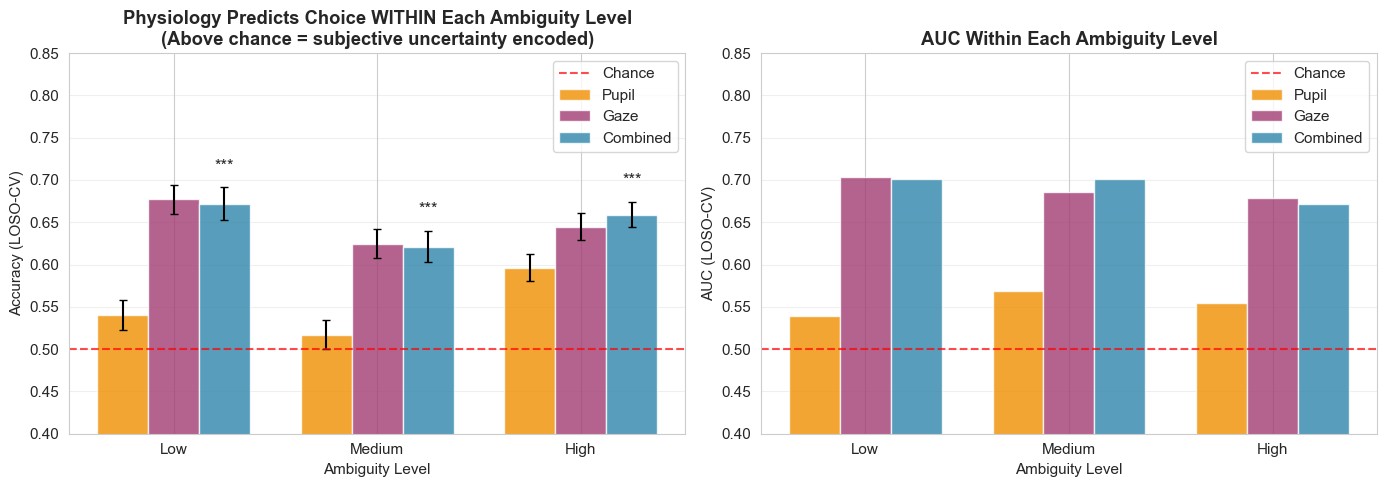

In [15]:
# Visualization: Accuracy within each ambiguity level
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart of accuracies
ax = axes[0]
x = np.arange(3)
width = 0.25

physio_vals = within_amb_df['physio_acc'].values
gaze_vals = within_amb_df['gaze_acc'].values
combined_vals = within_amb_df['combined_acc'].values

physio_err = within_amb_df['physio_acc_std'].values / np.sqrt(within_amb_df['n_subjects'].values)
gaze_err = within_amb_df['gaze_acc_std'].values / np.sqrt(within_amb_df['n_subjects'].values)
combined_err = within_amb_df['combined_acc_std'].values / np.sqrt(within_amb_df['n_subjects'].values)

ax.bar(x - width, physio_vals, width, yerr=physio_err, label='Pupil', color='#F18F01', alpha=0.8, capsize=3)
ax.bar(x, gaze_vals, width, yerr=gaze_err, label='Gaze', color='#A23B72', alpha=0.8, capsize=3)
ax.bar(x + width, combined_vals, width, yerr=combined_err, label='Combined', color='#2E86AB', alpha=0.8, capsize=3)

ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Chance')
ax.set_xticks(x)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_xlabel('Ambiguity Level')
ax.set_ylabel('Accuracy (LOSO-CV)')
ax.set_title('Physiology Predicts Choice WITHIN Each Ambiguity Level\n(Above chance = subjective uncertainty encoded)', fontweight='bold')
ax.legend()
ax.set_ylim([0.4, 0.85])
ax.grid(True, alpha=0.3, axis='y')

# Add significance stars
for i, p in enumerate(within_amb_df['vs_chance_p'].values):
    if p < 0.001:
        ax.text(i + width, combined_vals[i] + combined_err[i] + 0.02, '***', ha='center', fontsize=12)
    elif p < 0.01:
        ax.text(i + width, combined_vals[i] + combined_err[i] + 0.02, '**', ha='center', fontsize=12)
    elif p < 0.05:
        ax.text(i + width, combined_vals[i] + combined_err[i] + 0.02, '*', ha='center', fontsize=12)

# Plot 2: AUC comparison
ax = axes[1]
ax.bar(x - width, within_amb_df['physio_auc'].values, width, label='Pupil', color='#F18F01', alpha=0.8)
ax.bar(x, within_amb_df['gaze_auc'].values, width, label='Gaze', color='#A23B72', alpha=0.8)
ax.bar(x + width, within_amb_df['combined_auc'].values, width, label='Combined', color='#2E86AB', alpha=0.8)

ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Chance')
ax.set_xticks(x)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_xlabel('Ambiguity Level')
ax.set_ylabel('AUC (LOSO-CV)')
ax.set_title('AUC Within Each Ambiguity Level', fontweight='bold')
ax.legend()
ax.set_ylim([0.4, 0.85])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'physiology_within_ambiguity_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# Summary table
print("\n" + "="*70)
print("SUMMARY: PHYSIOLOGY PREDICTS CHOICE WITHIN AMBIGUITY LEVELS")
print("="*70)
print("\n" + within_amb_df[['ambiguity', 'physio_acc', 'gaze_acc', 'combined_acc', 'combined_auc', 'vs_chance_p']].to_string(index=False))

print("\n" + "-"*70)
print("INTERPRETATION:")
print("-"*70)
print("""
If physiology significantly predicts choice WITHIN each ambiguity level:
  → The brain encodes SUBJECTIVE uncertainty beyond task-defined ambiguity
  → Physiological signals reflect internal decision states, not just task difficulty
  → This is strong evidence for "mind-reading" of decision processes

Key insight: Even when task ambiguity is FIXED (e.g., all High ambiguity trials),
physiology can still differentiate INVEST vs KEEP choices. This means:
  - Different people experience the SAME objective ambiguity differently
  - Physiology captures this individual-level subjective uncertainty
""")

# Save results
within_amb_df.to_csv(OUTPUT_DIR / 'physiology_within_ambiguity_results.csv', index=False)
print(f"\nResults saved to: {OUTPUT_DIR / 'physiology_within_ambiguity_results.csv'}")


SUMMARY: PHYSIOLOGY PREDICTS CHOICE WITHIN AMBIGUITY LEVELS

ambiguity  physio_acc  gaze_acc  combined_acc  combined_auc  vs_chance_p
      Low    0.540356  0.676994      0.672183      0.701071 1.523908e-14
   Medium    0.516972  0.624741      0.621350      0.700811 2.069806e-09
     High    0.596463  0.644749      0.659166      0.672015 1.240515e-18

----------------------------------------------------------------------
INTERPRETATION:
----------------------------------------------------------------------

If physiology significantly predicts choice WITHIN each ambiguity level:
  → The brain encodes SUBJECTIVE uncertainty beyond task-defined ambiguity
  → Physiological signals reflect internal decision states, not just task difficulty
  → This is strong evidence for "mind-reading" of decision processes

Key insight: Even when task ambiguity is FIXED (e.g., all High ambiguity trials),
physiology can still differentiate INVEST vs KEEP choices. This means:
  - Different people experienc

## 7. Save Results

In [17]:
# Save results
gaze_effects_df.to_csv(OUTPUT_DIR / 'gaze_effect_sizes.csv', index=False)
gaze_amb_df.to_csv(OUTPUT_DIR / 'gaze_effects_by_ambiguity.csv', index=False)
corr_df.to_csv(OUTPUT_DIR / 'pupil_gaze_correlations.csv')

# Save pupil slope statistics
slope_stats = pd.DataFrame([
    {'choice': 'INVEST', 'mean_slope': np.mean(invest_slopes), 'std_slope': np.std(invest_slopes), 'n': len(invest_slopes)},
    {'choice': 'KEEP', 'mean_slope': np.mean(keep_slopes), 'std_slope': np.std(keep_slopes), 'n': len(keep_slopes)}
])
slope_stats.to_csv(OUTPUT_DIR / 'pupil_slope_statistics.csv', index=False)

print("\n" + "="*70)
print("FILES SAVED")
print("="*70)
for f in OUTPUT_DIR.glob('*'):
    print(f"  - {f.name}")


FILES SAVED
  - pupil_time_course_invest_vs_keep.png
  - physiology_within_ambiguity_prediction.png
  - gaze_effects_by_ambiguity.csv
  - gaze_effect_sizes.csv
  - pupil_time_course_by_ambiguity.png
  - pupil_gaze_correlations.png
  - pupil_slope_statistics.csv
  - pupil_gaze_correlations.csv
  - pupil_gaze_summary_figure.png
  - gaze_dispersion_by_choice.png
  - physiology_within_ambiguity_results.csv
